# Disaster tweet classification in Tensorflow

In [ ]:
# Get helper functions
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

--2026-06-08 18:26:05--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-06-08 18:26:05 (30.4 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [ ]:
from helper_functions import unzip_data, create_tensorboard_callback, plot_loss_curves, compare_historys, make_confusion_matrix, calculate_results

### Get a text dataset

In [ ]:
# Kaggle's introduction to NLP dataset
!wget https://storage.googleapis.com/ztm_tf_course/nlp_getting_started.zip

--2026-06-08 18:26:09--  https://storage.googleapis.com/ztm_tf_course/nlp_getting_started.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.199.207, 192.178.163.207, 142.251.188.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.199.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 607343 (593K) [application/zip]
Saving to: ‘nlp_getting_started.zip’

nlp_getting_started 100%[===================>] 593.11K  --.-KB/s    in 0.005s  

2026-06-08 18:26:09 (113 MB/s) - ‘nlp_getting_started.zip’ saved [607343/607343]



In [ ]:
# Unzip the data
unzip_data("nlp_getting_started.zip")

In [ ]:
# Let's visualize our data
import pandas as pd
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
train_df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [ ]:
train_df.text[3]

'13,000 people receive #wildfires evacuation orders in California '

In [ ]:
# shuffle training data
train_df_shuffled = train_df.sample(frac=1, random_state=42)
train_df_shuffled.head()

,id,keyword,location,text,target
2644,3796,destruction,NaN,So you have a new weapon that can cause un-ima...,1
2227,3185,deluge,NaN,The f$&amp;@ing things I do for #GISHWHES Just...,0
5448,7769,police,UK,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe...,1
132,191,aftershock,NaN,Aftershock back to school kick off was great. ...,0
6845,9810,trauma,"Montgomery County, MD",in response to trauma Children of Addicts deve...,0


In [ ]:
test_df.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3263 entries, 0 to 3262
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        3263 non-null   int64 
 1   keyword   3237 non-null   object
 2   location  2158 non-null   object
 3   text      3263 non-null   object
dtypes: int64(1), object(3)
memory usage: 102.1+ KB


In [ ]:
# View the distribution of target classes in the shuffled training data
train_df_shuffled.target.value_counts()

,count
target,
0,4342
1,3271


In [ ]:
len(train_df_shuffled), len(test_df)

(7613, 3263)

In [ ]:
train_df_shuffled.keyword.value_counts()

,count
keyword,
fatalities,45
armageddon,42
deluge,42
sinking,41
body%20bags,41
...,...
forest%20fire,19
epicentre,12
threat,11


In [ ]:
# check for the location of tweets that are disaster tagged
train_df_shuffled[['location', 'text']][train_df_shuffled.target == 1]

,location,text
2644,NaN,So you have a new weapon that can cause un-ima...
5448,UK,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe...
1765,NaN,my favorite lady came to our volunteer meeting...
1817,NaN,@brianroemmele UX fail of EMV - people want to...
4398,"Athens,Greece",The Murderous Story Of AmericaÛªs First Hijac...
...,...,...
466,NaN,#volleyball Attack II Volleyball Training Mach...
6265,NaN,kesabaran membuahkan hasil indah pada saat tep...
5734,NaN,VIDEO: 'We're picking up bodies from water': R...
7603,NaN,Officials say a quarantine is in place at an A...


In [ ]:
# lets visualize some random training examples
import random
random_index = random.randint(0, len(train_df)-5)
for row in train_df[["text", "target"]][random_index:random_index+5].itertuples():
  _, text, target = row
  print(f"{_}. target: {target} | ", "real disaster" if target > 0 else "not real disaster")
  print(f"text:\n{text}\n")

1891. target: 1 |  real disaster
text:
Man crushed to death by own car http://t.co/CrPO9DkW9v

1892. target: 1 |  real disaster
text:
A diamond is just a piece of charcoal that handled stress exceptionally well. We are hard pressed on every side but not crushed.2 cor4:8

1893. target: 0 |  not real disaster
text:
Wow! He crushed that! #EDWING #BlueJays

1894. target: 0 |  not real disaster
text:
Crushed the gym then crushed a butterfinger flurry clearly my priorities are straight ??

1895. target: 0 |  not real disaster
text:
WRAPUP 2-U.S. cable TV companies' shares crushed after Disney disappoints http://t.co/wWFACu6NFt



### Split data into training and validation sets

In [ ]:
from sklearn.model_selection import train_test_split
train_sentences, val_sentences, train_labels, val_labels = train_test_split(train_df_shuffled["text"],
                                                                  train_df_shuffled["target"],
                                                                  test_size=0.1,
                                                                  random_state=42,
                                                                  stratify=train_df_shuffled["target"])

In [ ]:
train_labels.value_counts()

,count
target,
0,3907
1,2944


In [ ]:
val_labels.value_counts()

,count
target,
0,435
1,327


In [ ]:
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight(class_weight="balanced",
                                            classes=np.unique(train_labels),
                                            y=train_labels)
class_weights = dict(enumerate(weights))
print(class_weights)

{0: np.float64(0.8767596621448682), 1: np.float64(1.1635529891304348)}


### Converting texts to numbers using Text vectorization

In [ ]:
import tensorflow as tf
# import text vectorization
from tensorflow.keras.layers import TextVectorization

# Use the default TextVectorization parameters
text_vectorizer = TextVectorization(max_tokens=10000,
                                    ngrams=(1, 2),
                                    output_mode="int",
                                    output_sequence_length=25)

In [ ]:
# Find the average number of words in the training tweets
round(sum([len(i.split()) for i in train_sentences])/len(train_sentences))

15

In [ ]:
# You can fit the text vectorizer to the training text
text_vectorizer.adapt(train_sentences)

In [ ]:
# choose a random sentence from train sentence and tokenize
random_sentence = random.choice(train_sentences)
print(f"Original text:\n{random_sentence}\
      \n\nVectorized version:")
text_vectorizer([random_sentence])

Original text:
Wondering if gold could gap up $50 on the jobs numbers tomorrow and just obliterate the shorts. A big player with guys could smash them      

Vectorized version:


<tf.Tensor: shape=(1, 25), dtype=int64, numpy=
array([[3868,   48, 3102,  150,    1,   26,  966,   11,    2, 1060, 4238,
         577,    7,   31,  585,    2,    1,    3,  429, 2574,   14,  733,
         150, 6911,   90]])>

In [ ]:
# get the unique words in the vocabulary
words_in_vocab = text_vectorizer.get_vocabulary()
words_in_vocab[-5:]

[np.str_('to limit'),
 np.str_('to learn'),
 np.str_('to iranians'),
 np.str_('to injured'),
 np.str_('to include')]

### Creating an embedding layer

In [ ]:
from tensorflow.keras import layers
embedding = layers.Embedding(input_dim=10000,
                             output_dim=128,
                             input_length=25)
embedding

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


<Embedding name=embedding, built=False>

In [ ]:
# choose a random sentence, tokenize and then embed
print(f"vECTORIZED VERSION: \n{text_vectorizer([random_sentence])}\n")
print(f"EMBEDDING VERSION: \n{embedding(text_vectorizer([random_sentence]))}")

vECTORIZED VERSION: 
[[3868   48 3102  150    1   26  966   11    2 1060 4238  577    7   31
   585    2    1    3  429 2574   14  733  150 6911   90]]

EMBEDDING VERSION: 
[[[-0.04380452  0.01458837 -0.01445113 ...  0.01816061  0.04489417
   -0.0112562 ]
  [ 0.04667015  0.00358738  0.03970281 ... -0.04201274 -0.03062325
   -0.03960986]
  [ 0.04335389  0.01517074 -0.02350392 ... -0.02321591  0.01999347
   -0.01281626]
  ...
  [ 0.01015585 -0.01867447  0.0251034  ...  0.02819556 -0.01126713
   -0.01003056]
  [ 0.02854044 -0.01900437  0.03991788 ...  0.00305324 -0.02891343
    0.03084523]
  [ 0.02448138 -0.04754722  0.00144404 ...  0.03108349  0.03394138
    0.00867419]]]


## Modelling a text dataset

In [ ]:
# using naive bayes for a baseline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
# Create a pipeline to pass our data into
model_0 = Pipeline([("tfidf", TfidfVectorizer(max_features=10000)),
                   ("clf", MultinomialNB())])
# Fit our model on the train_sentences
model_0.fit(train_sentences, train_labels)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=10000)),
                ('clf', MultinomialNB())])

In [ ]:
# Make predictions on our baseline model
predicted = model_0.predict(val_sentences)
print(f"Accuracy: {accuracy_score(val_labels, predicted) * 100:.2f}%")

Accuracy: 81.23%


In [ ]:
# Get the evaluation results of our baseline
model_0_results = calculate_results(val_labels, predicted)
model_0_results

{'accuracy': 81.23359580052494,
 'precision': 0.8207073080708661,
 'recall': 0.8123359580052494,
 'f1': 0.8074436056562}

### Building a FeedForward Neural Network for tyhe classification task

In [ ]:
# create a directory to save tensorboard logs
save_dir = "model_logs"

In [ ]:
# Build model using Sequential API
import tensorflow as tf
from tensorflow.keras import layers, Sequential
model_1 = Sequential([
    layers.Input(shape=(1,), dtype="string"),
    text_vectorizer,
    embedding,
    layers.GlobalAveragePooling1D(),
    layers.Dense(1, activation="sigmoid")
], name="model_1")

In [ ]:
model_1.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 25)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 25, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,129 (4.88 MB)

 Trainable params: 1,280,129 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile the model
model_1.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [ ]:
tf.random.set_seed(42)
# fit the model
history_1 = model_1.fit(train_sentences.to_numpy(),
                    train_labels,
                    epochs=5,
                    validation_data=(val_sentences.to_numpy(), val_labels),
                    callbacks=[create_tensorboard_callback(dir_name=save_dir,
                                                           experiment_name="model_1_dense")
                               ],
                    class_weight=class_weights)

Saving TensorBoard log files to: model_logs/model_1_dense/20260608-182615
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6771 - loss: 0.6318 - val_accuracy: 0.7979 - val_loss: 0.5416
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8076 - loss: 0.4756 - val_accuracy: 0.8176 - val_loss: 0.4604
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8482 - loss: 0.3885 - val_accuracy: 0.8176 - val_loss: 0.4348
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8724 - loss: 0.3317 - val_accuracy: 0.8176 - val_loss: 0.4279
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8915 - loss: 0.2881 - val_accuracy: 0.8215 - val_loss: 0.4323


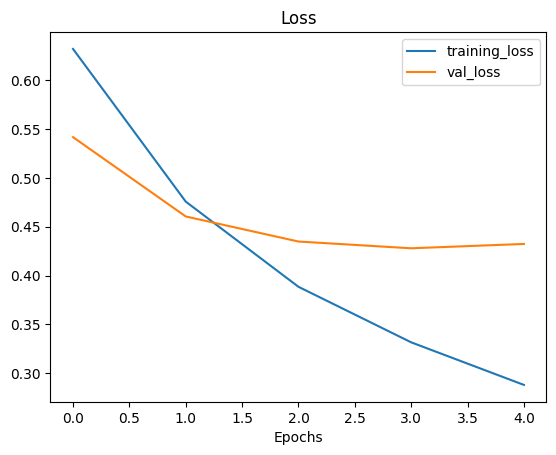

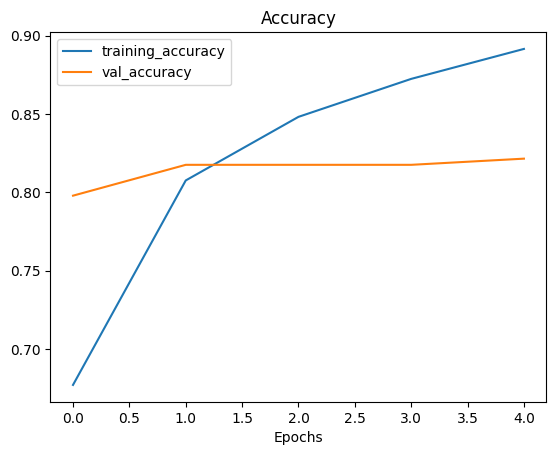

In [ ]:
plot_loss_curves(history_1)

In [ ]:
# evaluate our model
model_1.evaluate(val_sentences.to_numpy(), val_labels)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8215 - loss: 0.4323


[0.4323330819606781, 0.8215222954750061]

In [ ]:
# prediction probabilities
model_1_pred_probs = model_1.predict(val_sentences.to_numpy())
model_1_pred_probs.shape, model_1_pred_probs[0]

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


((762, 1), array([0.01110454], dtype=float32))

In [ ]:
model_1_results = calculate_results(val_labels, tf.squeeze(tf.round(model_1_pred_probs)))
model_1_results

{'accuracy': 82.1522309711286,
 'precision': 0.8246468601523912,
 'recall': 0.821522309711286,
 'f1': 0.818706070832055}

In [ ]:
# get the weights matrix of our embedded layer
model_1_weights = model_1.get_layer("embedding").get_weights()[0]
model_1_weights.shape

(10000, 128)

In [ ]:
# # Create embedding files
# import io
# out_v = io.open("vectors.tsv", "w", encoding="utf-8")
# out_meta = io.open("metadata.tsv", "w", encoding="utf-8")

# for index, word in enumerate(words_in_vocab):
#   if index == 0:
#     continue
#   vec = model_1_weights[index]
#   out_v.write("\t".join([str(x) for x in vec]) + "\n")
#   out_meta.write(word + "\n")
# out_v.close()
# out_meta.close()

In [ ]:
# # download file from colab to upload to projector tool
# try:
#   from google.colab import files
#   files.download("vectors.tsv")
#   files.download("metadata.tsv")
# except:
#   pass

## Recurrent Neural Network

#### Model2: LSTM

In [ ]:
# create an LSTM model
from tensorflow.keras import layers, Sequential
model_2 = Sequential([
    layers.Input(shape=(1,), dtype="string"),
    text_vectorizer,
    embedding,
    layers.LSTM(32, return_sequences=True), #when you're stacking RNN's, you need to turn on "return_sequences"
    layers.LSTM(32),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
], name="model_2_LSTM")

In [ ]:
model_2.summary()

Model: "model_2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 25)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 25, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 25, 32)         │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,311,105 (5.00 MB)

 Trainable params: 1,311,105 (5.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile the model
model_2.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [ ]:
history_2 = model_2.fit(train_sentences.to_numpy(),
                        train_labels,
                        epochs=5,
                        validation_data=(val_sentences.to_numpy(), val_labels),
                        callbacks=[create_tensorboard_callback(dir_name=save_dir,
                                                               experiment_name="model_2_LSTM")])

Saving TensorBoard log files to: model_logs/model_2_LSTM/20260608-182630
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.8939 - loss: 0.2913 - val_accuracy: 0.8084 - val_loss: 0.5077
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9229 - loss: 0.2064 - val_accuracy: 0.8097 - val_loss: 0.5788
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9345 - loss: 0.1692 - val_accuracy: 0.8071 - val_loss: 0.6396
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9477 - loss: 0.1394 - val_accuracy: 0.8031 - val_loss: 0.7017
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9527 - loss: 0.1227 - val_accuracy: 0.7979 - val_loss: 0.6334


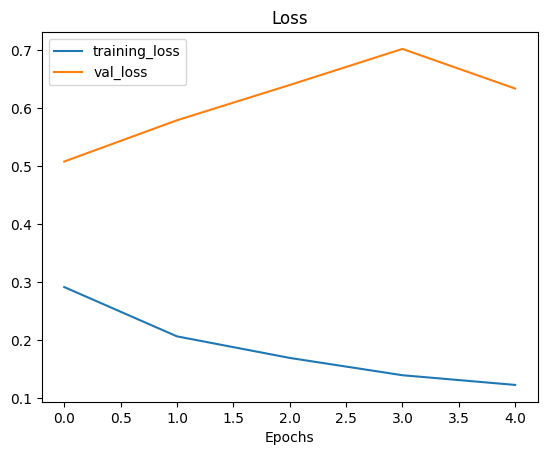

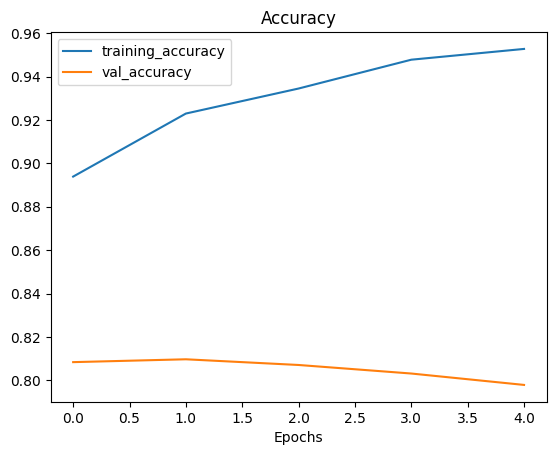

In [ ]:
plot_loss_curves(history_2)

In [ ]:
# make predictions on the val data
model_2_pred_probs = model_2.predict(val_sentences.to_numpy())
model_2_pred_probs[:10]

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


array([[0.00145492],
       [0.03455838],
       [0.923991  ],
       [0.06058392],
       [0.9878974 ],
       [0.09563451],
       [0.6270859 ],
       [0.00623561],
       [0.98634493],
       [0.99877673]], dtype=float32)

In [ ]:
model_2_pred = tf.squeeze(tf.round(model_2_pred_probs))
model_2_pred[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 0., 1., 0., 1., 0., 1., 0., 1., 1.], dtype=float32)>

In [ ]:
# calculate model's results
model_2_results = calculate_results(val_labels, model_2_pred)
model_2_results

{'accuracy': 79.79002624671917,
 'precision': 0.7973066702181574,
 'recall': 0.7979002624671916,
 'f1': 0.7966489198304829}

#### Model 3: GRU

In [ ]:
tf.random.set_seed(42)
# build a GRU model
from tensorflow.keras import layers, Sequential
model_3 = Sequential([
    layers.Input(shape=(1,), dtype="string"),
    text_vectorizer,
    embedding,
    layers.GRU(32, return_sequences=True),
    layers.GRU(32),
    layers.Dense(1, activation="sigmoid")
], name="model_3_GRU")

In [ ]:
# compile the model
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [ ]:
# Fit the model on training data
history_3 = model_3.fit(train_sentences.to_numpy(),
                        train_labels,
                        epochs=5,
                        validation_data=(val_sentences.to_numpy(), val_labels),
                        callbacks=[create_tensorboard_callback(dir_name=save_dir,
                                                               experiment_name="model_3_GRU")])

Saving TensorBoard log files to: model_logs/model_3_GRU/20260608-182703
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9146 - loss: 0.2211 - val_accuracy: 0.7861 - val_loss: 0.5846
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9600 - loss: 0.1190 - val_accuracy: 0.7743 - val_loss: 0.6764
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9618 - loss: 0.0992 - val_accuracy: 0.7835 - val_loss: 0.7371
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9658 - loss: 0.0864 - val_accuracy: 0.7756 - val_loss: 0.9120
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9656 - loss: 0.0842 - val_accuracy: 0.7848 - val_loss: 1.0739


In [ ]:
# make predictions with our GRU model
model_3_pred_probs = model_3.predict(val_sentences.to_numpy())
model_3_pred = tf.squeeze(tf.round(model_3_pred_probs))
model_3_pred[:10]

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 0., 1., 0., 1., 0., 1., 0., 1., 1.], dtype=float32)>

In [ ]:
# Calculate model 3 results
model_3_results = calculate_results(val_labels, model_3_pred)
model_3_results

{'accuracy': 78.4776902887139,
 'precision': 0.7852798124045357,
 'recall': 0.7847769028871391,
 'f1': 0.7820393130731101}

### Model 4: Bi-Directional

In [ ]:
tf.random.set_seed(42)
# build using the Bi-directional model
model_4 = Sequential([
    layers.Input(shape=(1,), dtype="string"),
    text_vectorizer,
    embedding,
    layers.Bidirectional(layers.LSTM(32, recurrent_dropout=0.2),
                         backward_layer=layers.GRU(32, go_backwards=True, recurrent_dropout=0.5)),
    layers.Dense(1, activation="sigmoid")
], name="model_4_bidirectional")

In [ ]:
# compile the model
model_4.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [ ]:
# fit the model
history_4 = model_4.fit(train_sentences.to_numpy(),
                        train_labels,
                        epochs=10,
                        validation_data=(val_sentences.to_numpy(), val_labels),
                        callbacks=[create_tensorboard_callback(dir_name=save_dir,
                                                               experiment_name="model_4_bidirectional"),
                                   tf.keras.callbacks.EarlyStopping(patience=2)],
                        class_weight=class_weights
                        )

Saving TensorBoard log files to: model_logs/model_4_bidirectional/20260608-182728
Epoch 1/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 42s 152ms/step - accuracy: 0.9343 - loss: 0.1986 - val_accuracy: 0.7887 - val_loss: 0.6501
Epoch 2/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 59s 248ms/step - accuracy: 0.9613 - loss: 0.1054 - val_accuracy: 0.7743 - val_loss: 0.7962
Epoch 3/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 40s 183ms/step - accuracy: 0.9673 - loss: 0.0838 - val_accuracy: 0.7730 - val_loss: 0.9307


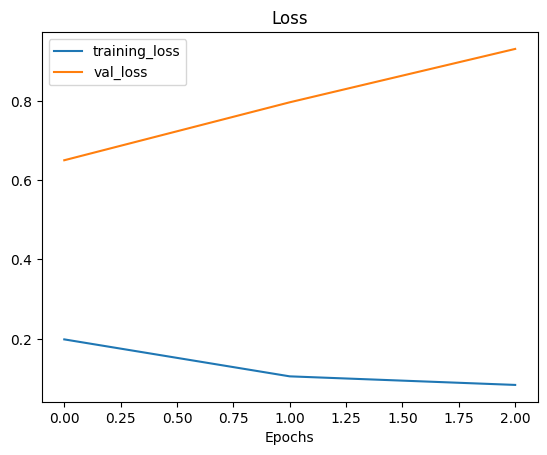

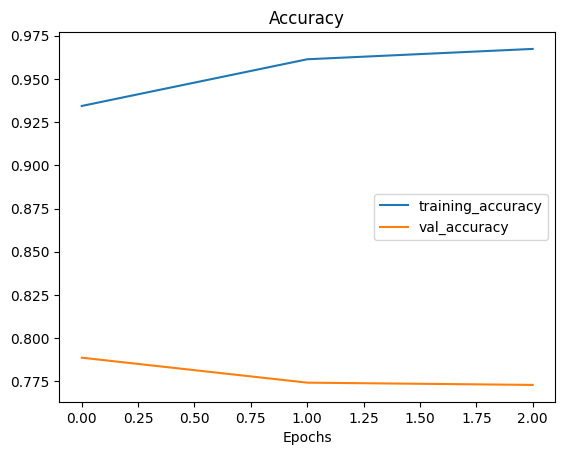

In [ ]:
# plot the loss curves
plot_loss_curves(history_4)

In [ ]:
# make predictions on the validation data
model_4_pred_probs = model_4.predict(val_sentences.to_numpy())
model_4_pred = tf.squeeze(tf.round(model_4_pred_probs))
model_4_pred[:10]

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 0., 1., 0., 1., 0., 1., 0., 1., 1.], dtype=float32)>

In [ ]:
# calculate the results of oyr predictions on the true label of val data
model_4_results = calculate_results(val_labels, model_4_pred)
model_4_results

{'accuracy': 77.29658792650919,
 'precision': 0.7727240192768902,
 'recall': 0.7729658792650919,
 'f1': 0.7728328521621861}

### Model 5: Conv1D Neural Network

In [ ]:
# set random seed
tf.random.set_seed(42)
# Build a conv1D Neural Network
model_5 = Sequential([
    text_vectorizer,
    embedding,
    layers.Dropout(0.3),
    layers.Conv1D(filters=64, kernel_size=3, padding="same", activation="relu"),
    layers.GlobalAveragePooling1D(),
    layers.Dense(1, activation="sigmoid")
], name="model_5_conv1D")

In [ ]:
# Compile the model
model_5.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [ ]:
model_5.summary()

Model: "model_5_conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 25)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 25, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,000 (4.88 MB)

 Trainable params: 1,280,000 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# fit the model
history_5 = model_5.fit(train_sentences.to_numpy(),
                        train_labels,
                        epochs=5,
                        validation_data=(val_sentences.to_numpy(), val_labels),
                        callbacks=[create_tensorboard_callback(dir_name=save_dir,
                                                               experiment_name="model_5_conv1D")],
                        class_weight=class_weights)

Saving TensorBoard log files to: model_logs/model_5_conv1D/20260608-182953
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9409 - loss: 0.2080 - val_accuracy: 0.7887 - val_loss: 0.6330
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9618 - loss: 0.1085 - val_accuracy: 0.7848 - val_loss: 0.7888
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9663 - loss: 0.0890 - val_accuracy: 0.7782 - val_loss: 0.9101
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9679 - loss: 0.0795 - val_accuracy: 0.7717 - val_loss: 1.0065
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9710 - loss: 0.0715 - val_accuracy: 0.7598 - val_loss: 1.0870


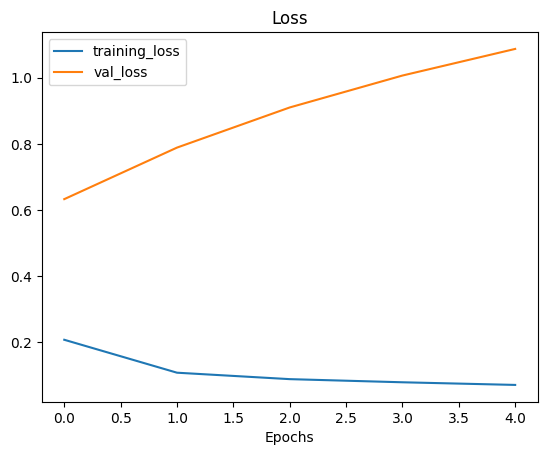

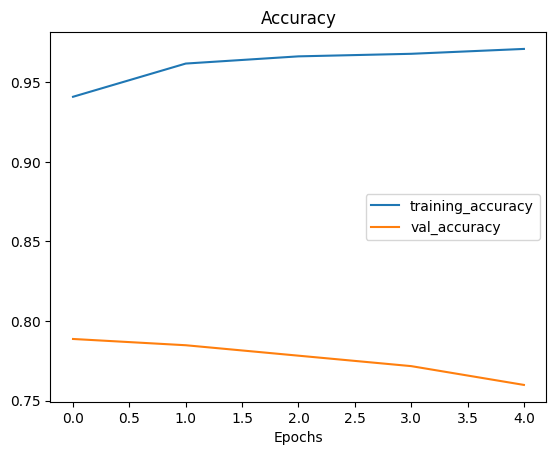

In [ ]:
# plot the loss curve
plot_loss_curves(history_5)

In [ ]:
model_5_pred_probs = model_5.predict(val_sentences.to_numpy())
model_5_pred = tf.squeeze(tf.round(model_5_pred_probs))
model_5_pred[:10]

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 0., 1., 0., 1., 0., 1., 0., 1., 1.], dtype=float32)>

In [ ]:
model_5_results = calculate_results(val_labels, model_5_pred)
model_5_results

{'accuracy': 75.98425196850394,
 'precision': 0.7613235897784869,
 'recall': 0.7598425196850394,
 'f1': 0.7603613871267952}

### Model 6: Universal sentence Encoder (USE)

In [ ]:
import tensorflow_hub as hub
embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

In [ ]:
embed_samples = embed(train_sentences)
embed_samples.shape

TensorShape([6851, 512])

In [ ]:
embed_samples[0].shape

TensorShape([512])

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import keras

print(tf.__version__)
print(keras.__version__)
print(hub.__version__)

2.20.0
3.13.2
0.16.1


In [ ]:
!pip install tf_keras

The error is caused by a version mismatch between Keras and TensorFlow Hub:

- TensorFlow version: 2.20.0
- Keras version: 3.13.2

hub.KerasLayer in TF Hub works with the Keras that comes bundled with TensorFlow, but in this case, there was a conflict with the standalone keras package installed in the environment.

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import tf_keras as keras

In [ ]:
# create a Keras layer using the USE pre trained layer from tensorflow hub
sentence_encoder_layer = hub.KerasLayer("https://tfhub.dev/google/universal-sentence-encoder/4",
                                      input_shape=[],
                                      dtype=tf.string,
                                      trainable=False,
                                      name="USE")

In [ ]:
# Create model using the Sequential API
tf.random.set_seed(42)
model_6 = keras.Sequential([
    sentence_encoder_layer,
    keras.layers.Dense(512, activation="relu"),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
], name="model_6_USE")

In [ ]:
model_6.summary()

Model: "model_6_USE"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 USE (KerasLayer)            (None, 512)               256797824 
                                                                 
 dense (Dense)               (None, 512)               262656    
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 64)                8256      
                                                                 
 dense_4 (Dense)             (None, 1)                 65        
                                                                 
Total params: 257233025 (981.27 MB)
Trainable params: 4

In [ ]:
# compile the model
model_6.compile(loss=keras.losses.BinaryCrossentropy(),
                optimizer=keras.optimizers.Adam(1e-4),
                metrics=["accuracy"])

In [ ]:
import datetime

# Redefine create_tensorboard_callback to use Keras 3 compatible TensorBoard
def create_tensorboard_callback_keras3(dir_name, experiment_name):
  log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback = keras.callbacks.TensorBoard(
      log_dir=log_dir
  )
  return tensorboard_callback

In [ ]:
# fit the model
history_6 = model_6.fit(train_sentences.to_numpy(),
                        train_labels,
                        epochs=5,
                        validation_data=(val_sentences.to_numpy(), val_labels),
                        callbacks=[create_tensorboard_callback_keras3(save_dir,
                                                               "model_6_USE")])

Epoch 1/5
215/215 [==============================] - 11s 30ms/step - loss: 0.5509 - accuracy: 0.7583 - val_loss: 0.4280 - val_accuracy: 0.8084
Epoch 2/5
215/215 [==============================] - 8s 38ms/step - loss: 0.4058 - accuracy: 0.8225 - val_loss: 0.4080 - val_accuracy: 0.8202
Epoch 3/5
215/215 [==============================] - 8s 36ms/step - loss: 0.3814 - accuracy: 0.8359 - val_loss: 0.4020 - val_accuracy: 0.8281
Epoch 4/5
215/215 [==============================] - 8s 35ms/step - loss: 0.3609 - accuracy: 0.8481 - val_loss: 0.4029 - val_accuracy: 0.8320
Epoch 5/5
215/215 [==============================] - 10s 47ms/step - loss: 0.3400 - accuracy: 0.8577 - val_loss: 0.4015 - val_accuracy: 0.8255


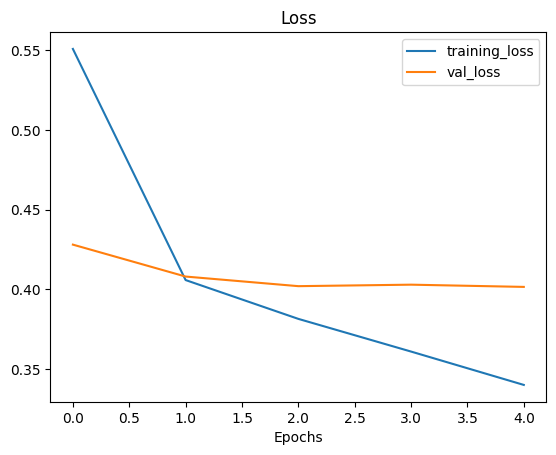

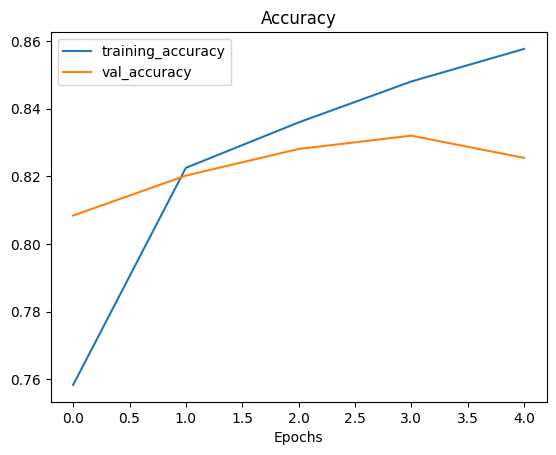

In [ ]:
plot_loss_curves(history_6)

In [ ]:
# make predictions on model_6
model_6_pred_probs = model_6.predict(val_sentences.to_numpy())
model_6_preds = tf.squeeze(tf.round(model_6_pred_probs))
model_6_preds[:10]

24/24 [==============================] - 1s 16ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 0., 1., 0., 1., 1., 0., 1., 1., 1.], dtype=float32)>

In [ ]:
# calculate the results of our model_6 performance
model_6_results = calculate_results(val_labels, model_6_preds)
model_6_results

{'accuracy': 82.54593175853019,
 'precision': 0.8254620699677641,
 'recall': 0.8254593175853019,
 'f1': 0.8242251460502921}

### Model 7: TF hub Pretrained USE but with 10% of training data

In [ ]:
train_sentences_10_percent = train_sentences[:int(len(train_sentences)*0.1)]
train_labels_10_percent = train_labels[:int(len(train_labels)*0.1)]

In [ ]:
# find the value counts of the target labels
train_labels_10_percent.value_counts()

,count
target,
0,403
1,282


In [ ]:
# get the class weights of train_labels_10_percent
from sklearn.utils import class_weight
weights = class_weight.compute_class_weight(class_weight="balanced",
                                            classes=np.unique(train_labels_10_percent),
                                            y=train_labels_10_percent)

In [ ]:
len(train_sentences_10_percent), len(train_labels_10_percent)

(685, 685)

In [ ]:
# fit model_6 on 10 percent of the data
model_7 = keras.models.clone_model(model_6)
model_7.compile(loss=keras.losses.BinaryCrossentropy(),
                optimizer=keras.optimizers.Adam(1e-4),
                metrics=["accuracy"])
history_7 = model_7.fit(train_sentences_10_percent,
         train_labels_10_percent,
         epochs=5,
         validation_data=(val_sentences.to_numpy(), val_labels),
         callbacks=[create_tensorboard_callback_keras3(save_dir,
                                                      "model_7_USE_10_percent")],
                        class_weight=dict(enumerate(weights)))

Epoch 1/5
22/22 [==============================] - 4s 48ms/step - loss: 0.6914 - accuracy: 0.6058 - val_loss: 0.6860 - val_accuracy: 0.6535
Epoch 2/5
22/22 [==============================] - 1s 26ms/step - loss: 0.6797 - accuracy: 0.7693 - val_loss: 0.6736 - val_accuracy: 0.7769
Epoch 3/5
22/22 [==============================] - 1s 44ms/step - loss: 0.6573 - accuracy: 0.8248 - val_loss: 0.6456 - val_accuracy: 0.7953
Epoch 4/5
22/22 [==============================] - 1s 40ms/step - loss: 0.6089 - accuracy: 0.8540 - val_loss: 0.5899 - val_accuracy: 0.7966
Epoch 5/5
22/22 [==============================] - 2s 71ms/step - loss: 0.5292 - accuracy: 0.8496 - val_loss: 0.5211 - val_accuracy: 0.7730


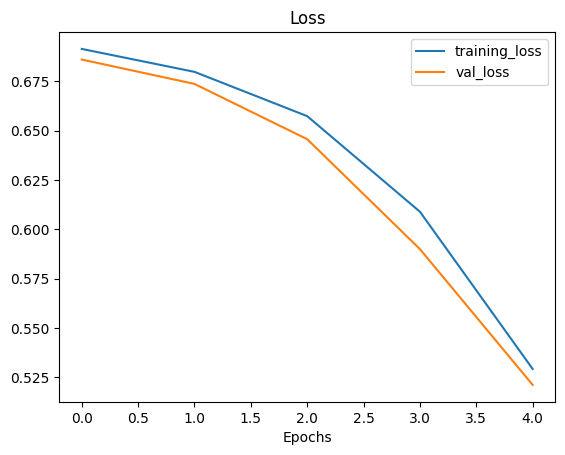

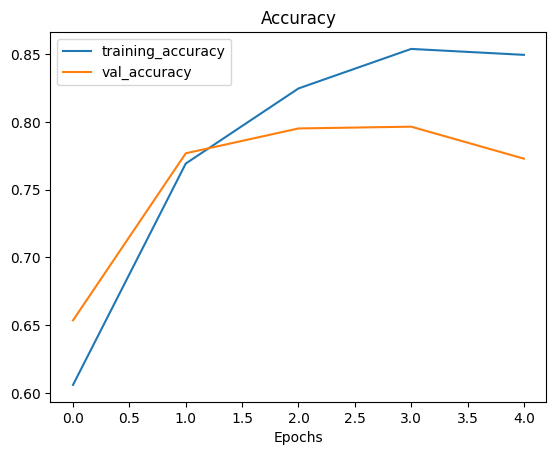

In [ ]:
# plot the loss curves
plot_loss_curves(history_7)

In [ ]:
# Make predictions on the model
model_7_pred_probs = model_7.predict(val_sentences.to_numpy())
model_7_preds = tf.squeeze(tf.round(model_7_pred_probs))
model_7_preds[:10]

24/24 [==============================] - 1s 11ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 0., 1., 1., 1., 1., 0., 1., 1., 1.], dtype=float32)>

In [ ]:
# evaluate the preds
model_7_results = calculate_results(val_labels, model_7_preds)
model_7_results

{'accuracy': 77.29658792650919,
 'precision': 0.7766354806970166,
 'recall': 0.7729658792650919,
 'f1': 0.7738307779331368}

### Comparing the performance of each of our models

In [ ]:
# combine model results into a DataFrame
all_model_results = pd.DataFrame({"Baseline": model_0_results,
                                 "simple Dense": model_1_results,
                                 "LSTM": model_2_results,
                                 "GRU": model_3_results,
                                 "Bidirectional": model_4_results,
                                 "Conv1D": model_5_results,
                                 "Universal_Sequence_encoder": model_6_results,
                                 "USE_10_PERCENT": model_7_results})
all_model_results = all_model_results.T
all_model_results

,accuracy,precision,recall,f1
Baseline,81.233596,0.820707,0.812336,0.807444
simple Dense,82.152231,0.824647,0.821522,0.818706
LSTM,79.790026,0.797307,0.797900,0.796649
GRU,78.477690,0.785280,0.784777,0.782039
Bidirectional,77.296588,0.772724,0.772966,0.772833
Conv1D,75.984252,0.761324,0.759843,0.760361
Universal_Sequence_encoder,82.545932,0.825462,0.825459,0.824225
USE_10_PERCENT,77.296588,0.776635,0.772966,0.773831


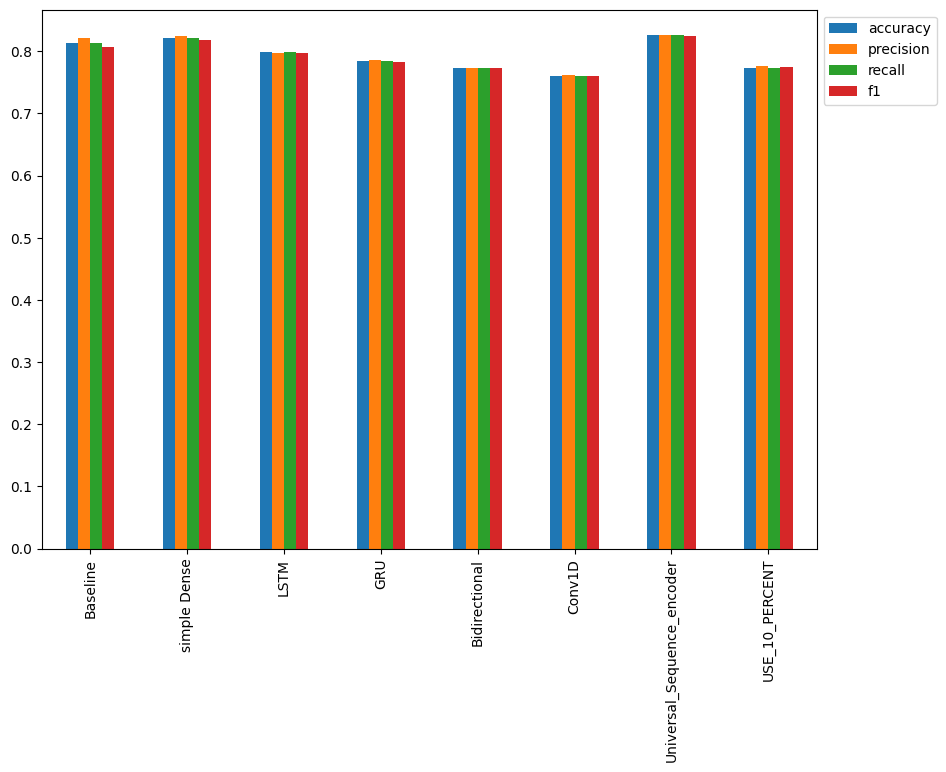

In [ ]:
# plot the model results
all_model_results["accuracy"] = all_model_results["accuracy"] / 100
all_model_results.plot.bar(figsize=(10, 7)).legend(bbox_to_anchor=(1.0, 1.0))

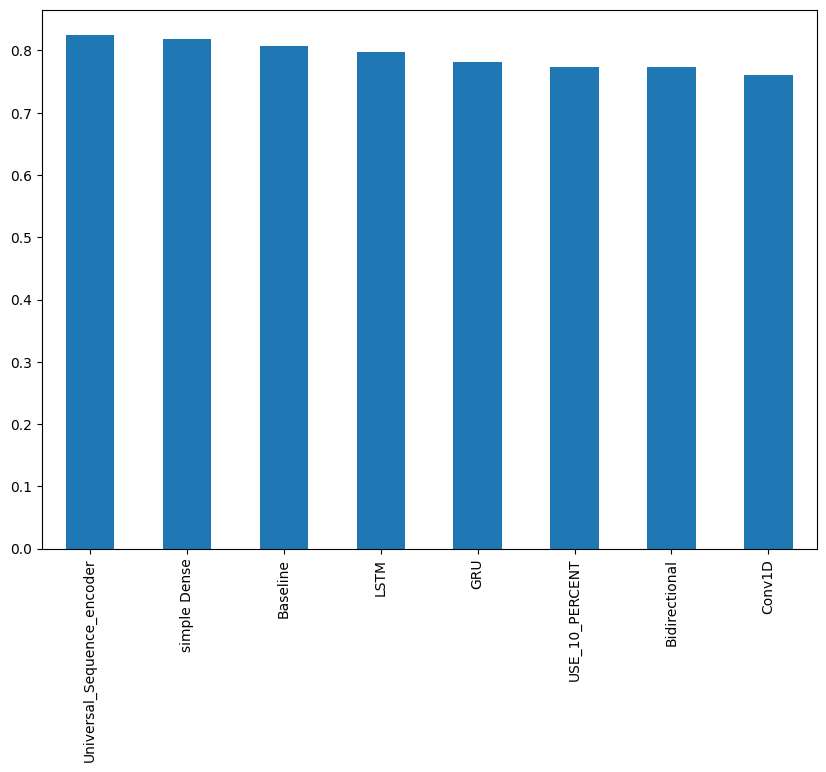

In [ ]:
# sort model results by f1 score
all_model_results.sort_values("f1", ascending=False)["f1"].plot(kind="bar", figsize=(10, 7));

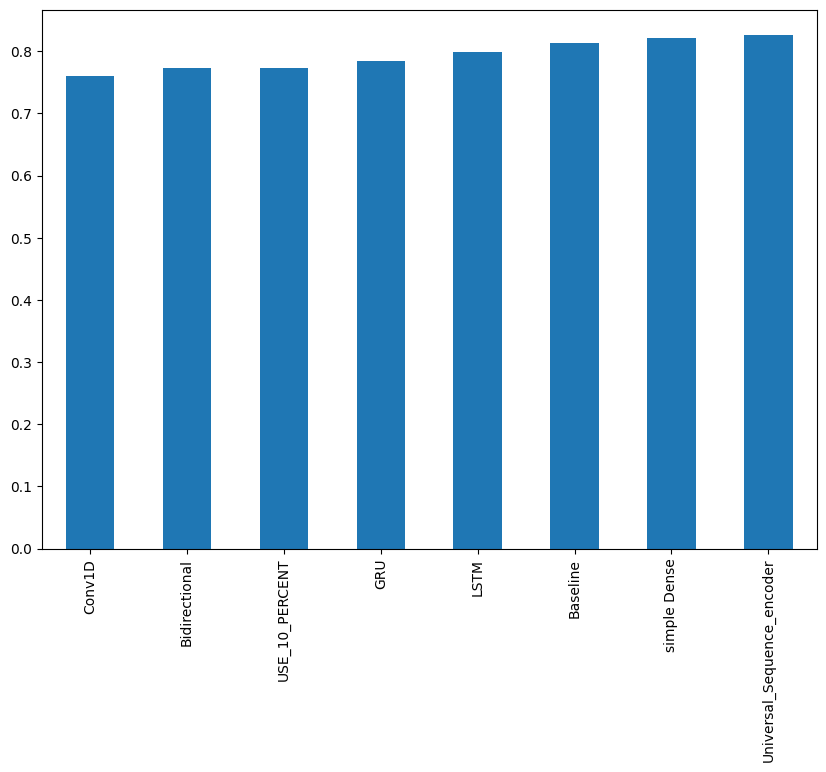

In [ ]:
# sort models accuracy and plot
all_model_results.sort_values("accuracy", ascending=True)["accuracy"].plot.bar(figsize=(10, 7));

#### Plot the model's performance using tensorboard

In [ ]:
# Load the TensorBoard notebook extension
%load_ext tensorboard

In [ ]:
import tensorflow as tf
import datetime, os

%tensorboard --logdir model_logs

<IPython.core.display.Javascript object>

### Saving and loading a trained model

In [ ]:
# Lets save our model
model_6.save("model_6.keras")

In [ ]:
import tensorflow_hub as hub
import tf_keras as keras # Ensure keras is tf_keras for consistent Keras 3 behavior
# load our model
loaded_model_6 = keras.models.load_model("model_6.keras", custom_objects={'KerasLayer': hub.KerasLayer})

In [ ]:
# evaluate our loaded model
loaded_model_6.evaluate(val_sentences, val_labels)

24/24 [==============================] - 1s 10ms/step - loss: 0.4015 - accuracy: 0.8255


[0.4015166461467743, 0.8254593014717102]

#### Let find the "most-wrong" predictions of our model

In [ ]:

loaded_model_6_pred_probs = loaded_model_6.predict(val_sentences)
loaded_model_6_pred_probs

24/24 [==============================] - 1s 11ms/step


array([[0.07016338],
       [0.08776559],
       [0.9157137 ],
       [0.39006332],
       [0.9948138 ],
       [0.916045  ],
       [0.23074923],
       [0.6301363 ],
       [0.9722338 ],
       [0.60269403],
       [0.07841458],
       [0.12851965],
       [0.9709435 ],
       [0.08001982],
       [0.15166384],
       [0.7695044 ],
       [0.06780475],
       [0.98937666],
       [0.9645654 ],
       [0.9656743 ],
       [0.9677615 ],
       [0.04582682],
       [0.24542803],
       [0.26308414],
       [0.7569947 ],
       [0.12868237],
       [0.04312921],
       [0.07291302],
       [0.11368009],
       [0.41660896],
       [0.1143406 ],
       [0.9693573 ],
       [0.10005615],
       [0.64489466],
       [0.08541432],
       [0.07609948],
       [0.94980323],
       [0.04860999],
       [0.98773205],
       [0.88260275],
       [0.54945743],
       [0.41954616],
       [0.14254715],
       [0.07810484],
       [0.98010135],
       [0.18500078],
       [0.15352778],
       [0.149

In [ ]:
val_sentences

,text
6778,Maaaaan I love Love Without Tragedy by @rihann...
971,?Ìü New Ladies Shoulder Tote #Handbag Faux Lea...
4821,@noah_anyname That's where the concentration c...
6074,Sinkhole Selfies: You Wont Believe What's In T...
3315,California wildfires force thousands to evacua...
...,...
1725,#Newswatch: 2 vehicles collided at Lock and La...
6117,Spent too many hours sinking into the wonderfu...
2848,Real people. True stories. Real pain &amp; suf...
4778,kabwandi_: Breaking news! Unconfirmed! I just ...


In [ ]:
import pandas as pd

# Convert val_labels Series to DataFrame
val_labels = pd.DataFrame(val_labels)

# Add prediction probabilities as a new column
val_labels["pred_probs"] = loaded_model_6_pred_probs

In [ ]:
# add val sentences
val_labels["text"] = val_sentences

In [ ]:
# arrange the columns in descending order of pred probs
val_labels = val_labels.sort_values("pred_probs", ascending=False)
val_labels

,target,pred_probs,text
1710,1,0.997617,Monsoon flooding - Monsoon rains have have hit...
201,1,0.997521,http://t.co/FueRk0gWui Twelve feared killed in...
187,1,0.997287,Pakistan air ambulance helicopter crash kills ...
7402,1,0.997246,Gunmen open fire on bus near El Salvador's cap...
3353,1,0.997188,Entire town of Roosevelt Wash. evacuated becau...
...,...,...,...
2956,0,0.035282,@JanieTheKillr Jack closed the sketchbook biti...
1044,0,0.034801,Bitches be takin pics with bags bigger than th...
4495,0,0.034538,@Hurricane_Dolce happy birthday big Bruh
7471,0,0.031361,Season 3 of New Girl was such a emotional trai...


In [ ]:
# get a column with very high prediction probability but wrong outcome(when pred_prob is greater than 0.5 but the true value is 0 and the vice versa)
val_labels["wrong_preds"] = (val_labels["pred_probs"].round()) == val_labels["target"]
val_labels

,target,pred_probs,text,wrong_preds
1710,1,0.997617,Monsoon flooding - Monsoon rains have have hit...,True
201,1,0.997521,http://t.co/FueRk0gWui Twelve feared killed in...,True
187,1,0.997287,Pakistan air ambulance helicopter crash kills ...,True
7402,1,0.997246,Gunmen open fire on bus near El Salvador's cap...,True
3353,1,0.997188,Entire town of Roosevelt Wash. evacuated becau...,True
...,...,...,...,...
2956,0,0.035282,@JanieTheKillr Jack closed the sketchbook biti...,True
1044,0,0.034801,Bitches be takin pics with bags bigger than th...,True
4495,0,0.034538,@Hurricane_Dolce happy birthday big Bruh,True
7471,0,0.031361,Season 3 of New Girl was such a emotional trai...,True


In [ ]:
# get all the rows with false in wrong preds
wrong_preds = val_labels[val_labels["wrong_preds"] == False]
wrong_preds.tail(30)

,target,pred_probs,text,wrong_preds
2255,1,0.148504,Tarp is protecting outfield and cannot be move...,False
5852,1,0.145285,Four Things That May Ruin Your Personal Injury...,False
5066,1,0.144631,This is the natural and unavoidable consequenc...,False
1765,1,0.144085,my favorite lady came to our volunteer meeting...,False
2946,1,0.143547,I got drowned like 5 times in the damn game to...,False
1461,1,0.138055,.@robdelaney Catastrophe is anything but! I l...,False
2239,1,0.122582,Here I'm the UK there isn't a deluge of Canadi...,False
2794,1,0.122285,Jeff Locke. Train wreck. F'in disaster. Fortun...,False
2531,1,0.118525,Fotoset: elanorofrohan: 10th December 2013 Gre...,False
4022,1,0.114330,I added a video to a @YouTube playlist http://...,False


In [ ]:
# check the false positives
for row in wrong_preds[:15].itertuples():
  _, target, pred_probs, text, fah = row
  print(f"Target: {target}, Pred Prob: {pred_probs}")
  print(f"Text:\n{text}\n")
  print("----")

Target: 0, Pred Prob: 0.9877840876579285
Text:
#hot  C-130 specially modified to land in a stadium and rescue hostages in Iran in 1980 http://t.co/zY3hpdJNwg #prebreak #best

----
Target: 0, Pred Prob: 0.9693573117256165
Text:
Episcopal priests on road trip with interracial family shares harrowing story of police harassment http://t.co/RG4JIsHyBs via @dailykos

----
Target: 0, Pred Prob: 0.930648922920227
Text:
Who is Tomislav Salopek the Islamic State's Most Recent Hostage? - http://t.co/wiQJERUktF

----
Target: 0, Pred Prob: 0.9170842170715332
Text:
[55436] 1950 LIONEL TRAINS SMOKE LOCOMOTIVES WITH MAGNE-TRACTION INSTRUCTIONS http://t.co/xEZBs3sq0y http://t.co/C2x0QoKGlY

----
Target: 0, Pred Prob: 0.9160450100898743
Text:
Weapons stolen from National Guard Armory in New Albany still missing #Gunsense http://t.co/lKNU8902JE

----
Target: 0, Pred Prob: 0.915729820728302
Text:
@RobertONeill31 Getting hit by a foul ball while sitting there is hardly a freak accident. It's a war zone.

-

In [ ]:
# visualize our false negatives
for row in wrong_preds[-15:].itertuples():
  _, target, pred_probs, text, fah = row
  print(f"target: {target}, Pred Prob: {pred_probs}")
  print(f"Text:\n{text}\n")
  print("----")

target: 1, Pred Prob: 0.088616281747818
Text:
Armageddon https://t.co/uCSUDk3q1d

----
target: 1, Pred Prob: 0.07790859043598175
Text:
@KopiteLuke1892 Its broken its fully exploded.

----
target: 1, Pred Prob: 0.07668238133192062
Text:
Now that's what you call a batting collapse #theashes

----
target: 1, Pred Prob: 0.07526101917028427
Text:
@OllyMursAus I do feel sorry for him! He is not a piece of meat! He is a nice guy... People don't need to rush him and screams in his face!

----
target: 1, Pred Prob: 0.06891435384750366
Text:
@Yankees body bagging mfs

----
target: 1, Pred Prob: 0.060402050614356995
Text:
#hiphop #news #indie Apollo Brown ÛÒ ÛÏDetonateÛ Ft. M.O.P. - &lt;a href='http://t.co/WnowfVCbMs... http://t.co/JxWOjxqndC

----
target: 1, Pred Prob: 0.055745553225278854
Text:
@allen_enbot If you mess up it's gonna explode...

----
target: 1, Pred Prob: 0.055071767419576645
Text:
This is set to become a huge one month wonder. (And then Pornhub will be inundated....) http:/

Our dataset is poorly labeled. We would need to make changes to our dataset to improve the models performance

In [ ]:
test_sentences = test_df["text"]

In [ ]:
predictions = loaded_model_6.predict(test_sentences.to_numpy())
predictions

102/102 [==============================] - 1s 10ms/step


array([[0.7496825 ],
       [0.9529605 ],
       [0.9259528 ],
       ...,
       [0.9692435 ],
       [0.76120406],
       [0.6147131 ]], dtype=float32)

#### Making prediction on custom tweets

In [ ]:
tweets = ["I would love to see this mountain destroyed into pieces. It's obstructing my way",
          "Flood has ravaged this community for the last three days",
          "I love Jesus. He is my friend",
          "The coming landslide has been a thing of concern for the surrounding communities"]

In [ ]:
preds = loaded_model_6.predict(tweets)
preds

1/1 [==============================] - 0s 44ms/step


array([[0.19982499],
       [0.58629054],
       [0.06798749],
       [0.91361636]], dtype=float32)

### from our custom tweets, we see our model is making correct predictions but out data is wrongly labelled and that's why it is making wrong predictions on our data

24/24 [==============================] - 0s 11ms/step


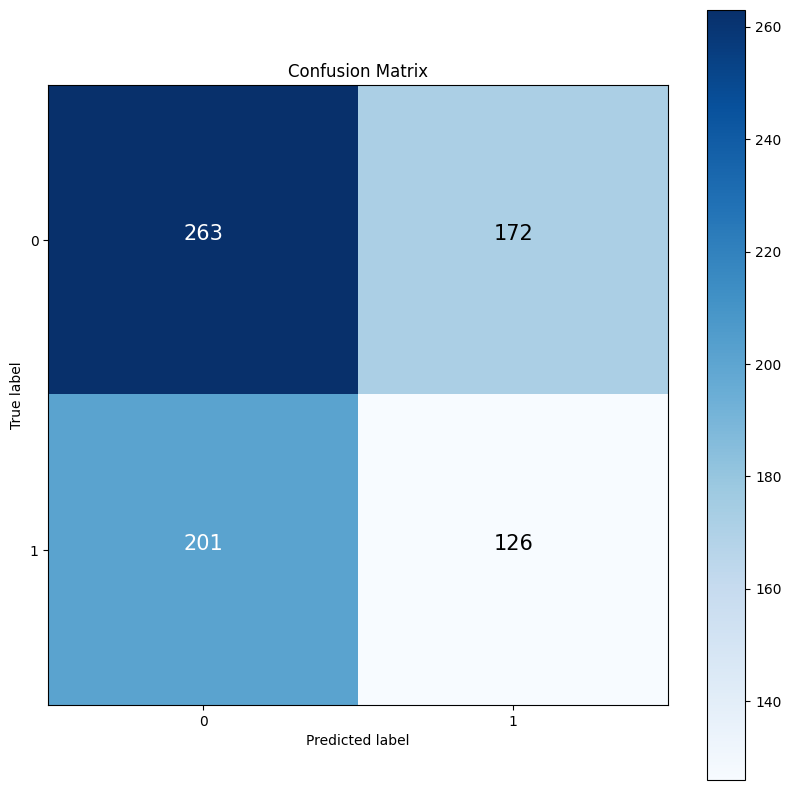

In [ ]:
make_confusion_matrix(val_labels["target"], tf.squeeze(tf.round(loaded_model_6.predict(val_sentences.to_numpy()))))

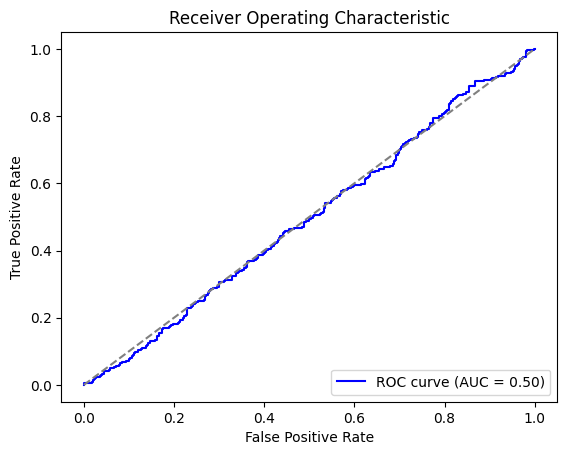

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming y_true and y_pred_proba are defined
fpr, tpr, _ = roc_curve(val_labels["target"], loaded_model_6_pred_probs.ravel())
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()
